# Lab: Vision & Language - CLIP for Classification and Retrieval

**Course:** Deep Learning: Advanced Models and Methods

**Instructor:** Antonino Furnari

**Duration:** 2 Hours (In-class Group Lab)

## 📝 Lab Format & Deliverables
* **Format:**
  * Students work in groups of 1-3.
  * The teacher gives a brief introduction to the lab, then students work independently with support from the teacher.
* **Strategy:**
  * Fill in the ☑️ `TODO` blocks. Do not modify the provided boilerplate unless necessary.
  * Check that you obtained reasonable results through the 🛑 `Checkpoints`.
  * Fill in the short 📝 `Reflections` where required.
  * Reach 🏁 `Milestones`.
* **Submission:**
  * Fill in this notebook and send it to <antonino.furnari@unict.it> as an `.ipynb` by the end of the lab
* **Grading:**
  * Notebooks will be graded in binary way as passed / not passed based on completion (did the group reach all milestones successfully? are reflections adequate?)
  * Each notebook is worth $0.5$ bonus points. These are assigned to students individually (not to groups).
* **Computation:**
  * Run this notebook on Google Colab or Kaggle with GPU acceleration.

You will find the following blocks throughout the notebook:

> ☑️ **TODO**
>
> This box provides you instruction on a TODO that should be completed in the code cells below.

> 🛑 **Checkpoint**
>
> The following cells provide you instruction on what you should observe if you run a given cell after having implemented your TODOs. This serve as a self-check to assess potential bugs or errors early.


> 📝 **Reflection**
>
> You are required to write a short reflection on your results.

> 🏁 **Milestone**
>
> This signal that you completed a significant part of the notebook and reached a milestone.

## Your Data
> 📝 **Date and Team Composition**
>
> <i>Insert the current date, plus names, surnames, matricola, and emails of the team members below:</i>
>
> **Date:** YYYY-MM-DD
>
> **Link to wandb:** <a href="example_link">link</a>
>
> | Name | Surname | Matricola | Email |
> |---|---:|---:|---|
> | Name 1 | Surname1 | 0000001 | <a href="mailto:member1@example.com">member1@example.com</a> |
> | Name 2 | Surname2 | 0000002 | <a href="mailto:member2@example.com">member2@example.com</a> |
> | Name 3 | Surname3 | 0000003 | <a href="mailto:member3@example.com">member3@example.com</a> |

## Introduction and Problem Setup

### 🎯 Learning Goals
In this lab, you will explore **Vision & Language Foundation Models**, specifically focusing on **CLIP (Contrastive Language-Image Pre-training)**.

You will familiarize with the core mechanisms that allow these models to project images and text into a shared semantic embedding space, applying them to two distinct paradigms:

1. **Image Classification (CIFAR-100):**
   * **Zero-Shot:** Predict classes using raw text prompts without any training.
   * **Linear Probing:** Train a linear classifier on top of frozen CLIP features to boost performance.
   
2. **Cross-Modal Retrieval (Fashion Products):**
   * **Off-the-shelf Retrieval:** Use CLIP to search for specific images using raw text queries.
   * **Adapter Fine-Tuning:** Train a lightweight Multi-Layer Perceptron (MLP) adapter using InfoNCE loss to specialize the embedding space.

### Problem Setup
Traditional architectures (e.g., ResNet, ViT) learn fixed taxonomies. If you want to detect a new class, you must collect new data and retrain the classifier head.

CLIP bypasses this by learning from natural language supervision. It is trained to maximize the cosine similarity between an image and its corresponding text caption in a joint embedding space. This enables powerful downstream applications like **Cross-Modal Retrieval**, where we can search a database of millions of images using natural language queries (Text-to-Image).

### The Datasets
1. **CIFAR-100:** We will use this classic dataset to evaluate zero-shot classification and linear probing.
2. **Fashion Product:** To keep this lab manageable within 2 hours, we will use a small dataset of fashion product images and related captions.

### Prerequisites
Let's install the prerequisites:

In [1]:
# @title ⚙️ Installation
# RUN THIS CELL FIRST TO INSTALL DEPENDENCIES
!pip install -q pytorch-lightning wandb torchmetrics datasets scikit-learn seaborn git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done


In [2]:
# @title ⚙️ Imports and Setup
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import clip
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR100
from datasets import load_dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
import wandb
from tqdm import tqdm

# Configuration
pl.seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Setup complete. Using device: {device}")

# Helper Function for Plotting
def plot_smoothed_curve(history, title, ylabel="Loss"):
    """Plots training curves with smoothing for better readability."""
    if not history: return
    window = max(1, len(history) // 10)
    smoothed = pd.Series(history).rolling(window=window, min_periods=1).mean()
    plt.figure(figsize=(8, 4))
    plt.plot(history, alpha=0.3, label=f'Raw {ylabel}')
    plt.plot(smoothed, color='blue', linewidth=2, label=f'Smoothed {ylabel}')
    plt.title(title)
    plt.xlabel("Training Steps")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Weights & Biases Login
WANDB_PROJECT = "dl-lab-vision-and-language-extended"
print("\n🚀 Logging in to Weights & Biases...")
try:
    wandb.login()
    print(f"✅ Login successful! Runs will be logged to project: '{WANDB_PROJECT}'")
except Exception as e:
    print(f"⚠️ Login failed: {e}")
    print("⚠️ Switching to OFFLINE mode. Metrics will be saved locally.")
    os.environ["WANDB_MODE"] = "offline"

INFO:lightning_fabric.utilities.seed:Seed set to 42


✅ Setup complete. Using device: cuda

🚀 Logging in to Weights & Biases...


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: antoninofurnari to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ Login successful! Runs will be logged to project: 'dl-lab-vision-and-language-extended'


# SECTION A: CLASSIFICATION ON CIFAR-100

Let's begin by loading the CLIP model and extracting features for the **CIFAR-100** dataset. Please note that, since we are pre-extracting features, this may take a couple of minutes.

CIFAR-100 is similar to CIFAR-10, but images are divided into 100 categories, rather than 10.

<img src="https://storage.googleapis.com/kaggle-datasets-images/1059701/1782442/763cab8e6130dad7ff7102abdfef54a0/dataset-card.jpg?t=2020-12-26-08-56-16">

More information on the dataset are here: https://www.cs.toronto.edu/~kriz/cifar.html

We'll begin by downloading the dataset and extracting CLIP features:

In [3]:
print("⏳ Loading CLIP Model...")
model_clip, preprocess = clip.load("ViT-B/32", device=device)
model_clip.eval() # We strictly use CLIP as a frozen feature extractor

print("⏳ Downloading CIFAR-100 dataset...")
cifar_train = CIFAR100(root="data", train=True, download=True, transform=preprocess)
cifar_test = CIFAR100(root="data", train=False, download=True, transform=preprocess)
cifar_classes = cifar_test.classes

def extract_cifar_features(dataset):
    loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=2)
    features, labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Extracting CIFAR"):
            features.append(model_clip.encode_image(imgs.to(device)).cpu())
            labels.append(lbls)
    return torch.cat(features), torch.cat(labels)

print("\n➡️ Extracting CIFAR-100 Features...")
cifar_train_feats, cifar_train_labels = extract_cifar_features(cifar_train)
cifar_test_feats, cifar_test_labels = extract_cifar_features(cifar_test)

# Normalize features (L2 normalization is standard for cosine similarity)
cifar_train_feats_norm = F.normalize(cifar_train_feats.float(), p=2, dim=1)
cifar_test_feats_norm = F.normalize(cifar_test_feats.float(), p=2, dim=1)

⏳ Loading CLIP Model...
⏳ Downloading CIFAR-100 dataset...

➡️ Extracting CIFAR-100 Features...


Extracting CIFAR: 100%|██████████| 40/40 [00:22<00:00,  1.77it/s]


## Part 1: Zero-Shot Classification
Standard CNNs fail when presented with a class name they weren't trained on. CLIP solves this by aligning images with natural language descriptions.

Let's see a simple example where we:
- select a random image;
- select 10 random classes (including the ground truth one);
- composing the textual prompts with a template "a photo of {}"
- represent the image and the prompts;
- compute cosine similarity between the image representation and each prompt;
- pass similarities through a softmax;
- display the output probability distribution.

🔍 Zero-Shot Classification Demonstration
a photo of a plate
a photo of a bowl
a photo of a bottle
a photo of a lion
a photo of a flatfish
a photo of a spider
a photo of a baby
a photo of a kangaroo
a photo of a poppy
a photo of a orange


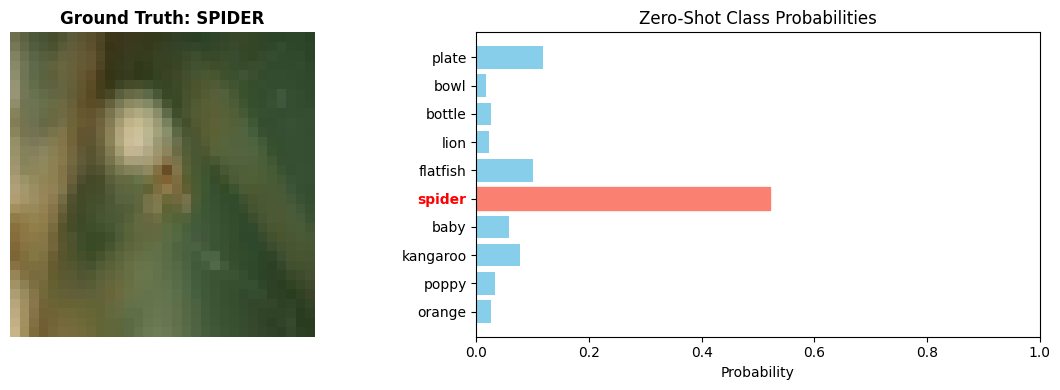

In [4]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

print("🔍 Zero-Shot Classification Demonstration")

random.seed(45) #for repeatability

# 1. Select a random image
test_idx = random.randint(0, len(cifar_test) - 1)
img_tensor, gt_label_idx = cifar_test[test_idx]
gt_class_name = cifar_classes[gt_label_idx]

# To display the image properly, we fetch the raw un-normalized PIL image
raw_image = CIFAR100(root="data", train=False, download=False)[test_idx][0]

# 2. Select 10 random classes (including the ground truth one)
num_candidates = 10
other_classes = [c for i, c in enumerate(cifar_classes) if i != gt_label_idx]
candidate_classes = random.sample(other_classes, num_candidates - 1)
candidate_classes.append(gt_class_name)
random.shuffle(candidate_classes) # Shuffle so the GT isn't always at the bottom

# 3. Compose textual prompts
prompts = [f"a photo of a {c}" for c in candidate_classes]
print("\n".join(prompts))
text_tokens = clip.tokenize(prompts).to(device)
img_input = img_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    # 4. Represent the image and the prompts
    image_features = model_clip.encode_image(img_input).float()
    text_features = model_clip.encode_text(text_tokens).float()

    # Normalize features (as during training)
    image_features = F.normalize(image_features, p=2, dim=-1)
    text_features = F.normalize(text_features, p=2, dim=-1)

    # 5. Compute cosine similarity (scaled by CLIP's learned temperature)
    logit_scale = model_clip.logit_scale.exp()
    logits = logit_scale * image_features @ text_features.T

    # 6. Pass similarities through a softmax
    probs = logits.softmax(dim=-1).cpu().numpy().squeeze()

# 7. Display the output probability distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot Image
ax1.imshow(raw_image)
ax1.set_title(f"Ground Truth: {gt_class_name.upper()}", fontweight="bold")
ax1.axis("off")

# Plot Probabilities
y_pos = np.arange(len(candidate_classes))
bars = ax2.barh(y_pos, probs, align='center', color='skyblue')
ax2.set_yticks(y_pos, labels=candidate_classes)
ax2.invert_yaxis()  # labels read top-to-bottom
ax2.set_xlabel('Probability')
ax2.set_title('Zero-Shot Class Probabilities')
ax2.set_xlim(0, 1.0)

# Highlight ground truth in red
gt_index = candidate_classes.index(gt_class_name)
bars[gt_index].set_color('salmon')
ax2.get_yticklabels()[gt_index].set_color("red")
ax2.get_yticklabels()[gt_index].set_fontweight("bold")

plt.tight_layout()
plt.show()

> 📝 **Reflection 1**
>
> *Play with the seed to pick different images. Comment on the results. When is the model uncertain? When does it make mistakes?*
>
> Your text

Let's now implement this in scale and classify the whole test set:

> ☑️ **TODO 1: Implement Zero-Shot Prediction**
>
> 1. Create text prompts for all 100 classes using the template `"a photo of a {class_name}"`.
> 2. Encode the text prompts using `model_clip.encode_text`.
> 3. L2 Normalize the text features.
> 4. Compute the logits (cosine similarity * 100.0) between the test images and text features.
> 5. Apply argmax to get the predicted classes.


🚀 Performing Zero-Shot Classification...
✅ Zero-Shot Top-1 Accuracy: 61.68%


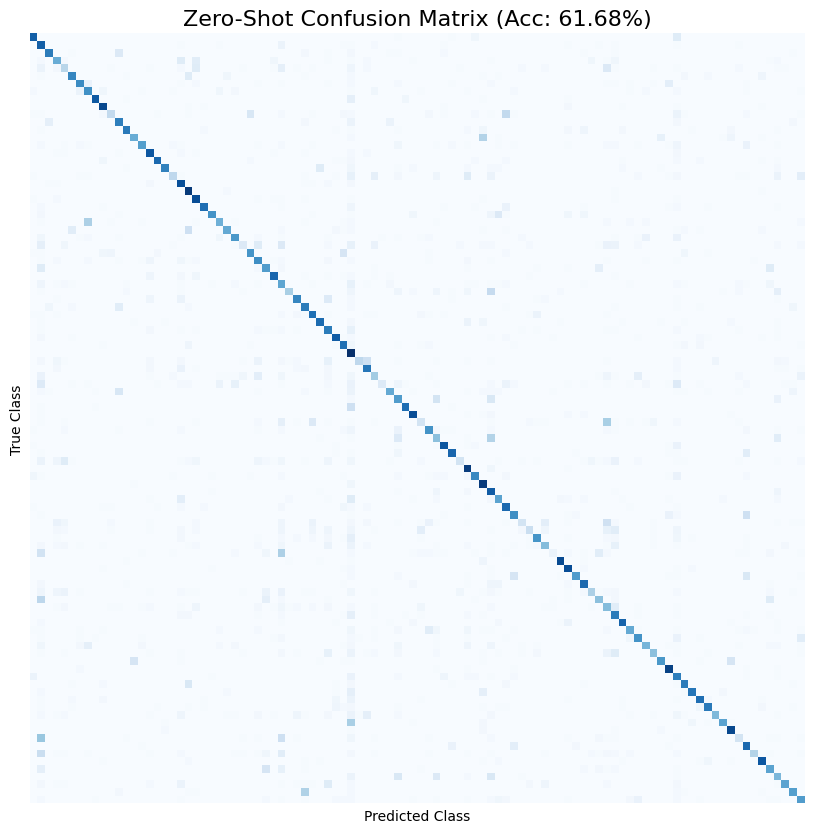

In [14]:
print("\n🚀 Performing Zero-Shot Classification...")

# 1. Create text prompts and tokenize. Define:
# prompts: a list of prompts
# text_tokens: tokenize the list with clip
# <YOUR CODE HERE>

# </YOUR CODE HERE>

with torch.no_grad():
    # 2 & 3. Encode and normalize text features using model_clip and F.normalize
    # <YOUR CODE HERE>
    
    # </YOUR CODE HERE>

# 4. Compute similarity / logits
# Shape: (N_images, 512) @ (512, N_classes) -> (N_images, N_classes)
# <YOUR CODE HERE>

# </YOUR CODE HERE>


# 5. Get predictions via argmax
# <YOUR CODE HERE>

# </YOUR CODE HERE>

# Evaluate Accuracy
zero_shot_acc = (preds_zero_shot == cifar_test_labels).float().mean().item() * 100
print(f"✅ Zero-Shot Top-1 Accuracy: {zero_shot_acc:.2f}%")

# Plot Confusion Matrix
def plot_cifar_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 10))
    sns.heatmap(cm, cmap="Blues", cbar=False, xticklabels=False, yticklabels=False)
    plt.title(title, fontsize=16)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.show()

plot_cifar_confusion_matrix(cifar_test_labels, preds_zero_shot, f"Zero-Shot Confusion Matrix (Acc: {zero_shot_acc:.2f}%)")

> 📝 **Reflection 2**
>
> *Observe the confusion matrix. Are there blocky patterns along the diagonal? This implies the model is confusing semantically similar classes (e.g., different breeds of dogs or types of trees). Why might zero-shot CLIP struggle with fine-grained distinctions compared to a model explicitly trained on the CIFAR-100 labels? Is the obtained accuracy reasonable?*
>
> Your text

## Part 2: Linear Probing
Zero-shot is great, but if we have labeled data, we can do better! We will freeze the CLIP backbone and train a single Linear Layer (Logistic Regression) on top of the extracted features.



> ☑️ **TODO 2: Implement Linear Probing**
>
> Define a simple `nn.Linear` layer that maps the 512-dimensional CLIP features to the 100 CIFAR classes.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.



🚀 Training Linear Probe...


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ classifier │ Linear           │ 51.3 K │ train │     0 │
│ 1 │ criterion  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 51.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 51.3 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 2                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


epoch,▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇████
probe/train_loss,█▆▅▄▃▃▂▂▂▂▂▂▂▂▁▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
epoch,9
probe/train_loss,0.66503
trainer/global_step,1949


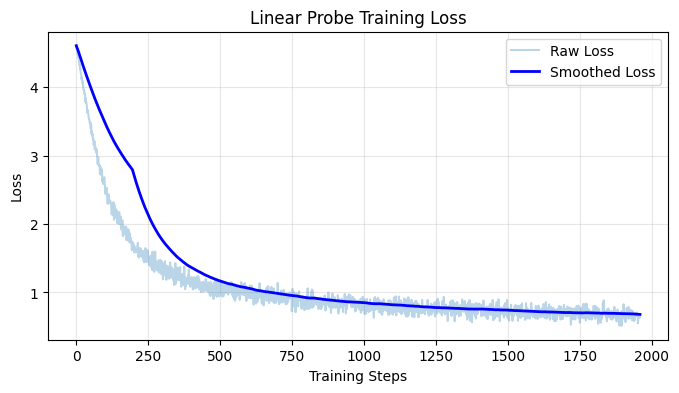


📊 Evaluating Linear Probe on Test Set...
✅ Linear Probe Top-1 Accuracy: 78.48% (Improvement over Zero-Shot: +16.80%)


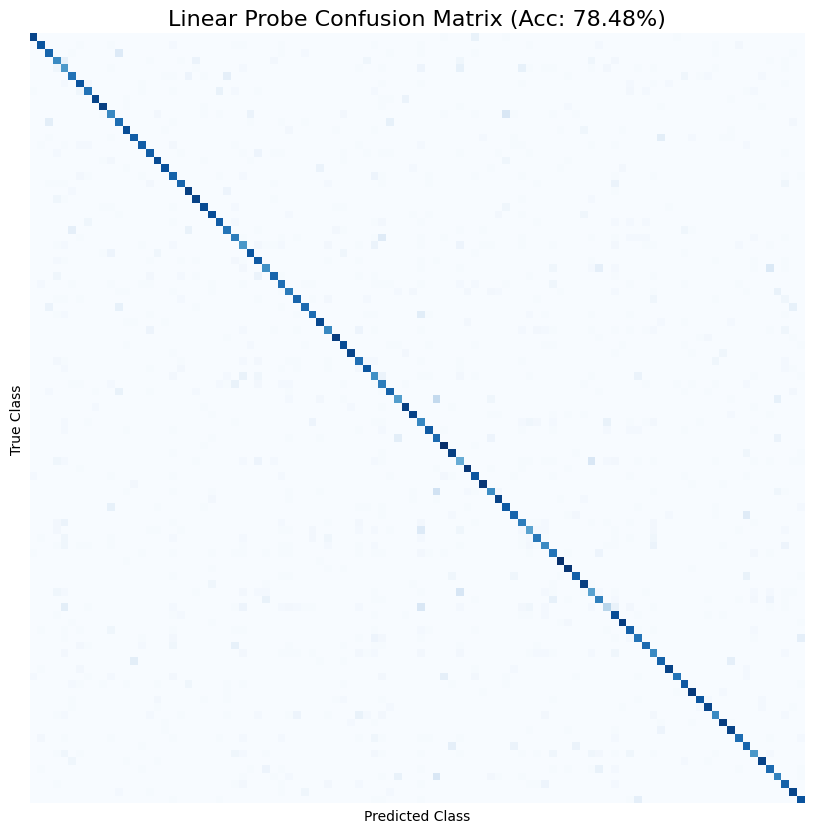

In [6]:
class LinearProbeTask(pl.LightningModule):
    def __init__(self, input_dim=512, num_classes=100, lr=1e-3):
        super().__init__()
        self.lr = lr
        # Define self.classifier
        # <YOUR CODE HERE>
        
        # </YOUR CODE HERE>
        self.criterion = nn.CrossEntropyLoss()
        self.train_loss_hist = []

    def forward(self, x):
        return self.classifier(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.train_loss_hist.append(loss.item())
        self.log("probe/train_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

# Create DataLoaders
cifar_train_loader = DataLoader(TensorDataset(cifar_train_feats_norm, cifar_train_labels), batch_size=256, shuffle=True)
cifar_test_loader = DataLoader(TensorDataset(cifar_test_feats_norm, cifar_test_labels), batch_size=256, shuffle=False)

print("\n🚀 Training Linear Probe...")
probe_task = LinearProbeTask(lr=1e-2)
logger_probe = WandbLogger(project=WANDB_PROJECT, name="Linear_Probe_CIFAR")

trainer_probe = pl.Trainer(max_epochs=10, accelerator="auto", devices=1, logger=logger_probe, enable_checkpointing=False)
trainer_probe.fit(probe_task, cifar_train_loader)
wandb.finish()

# Plot Training Curve
plot_smoothed_curve(probe_task.train_loss_hist, "Linear Probe Training Loss")

# Evaluate Linear Probe
print("\n📊 Evaluating Linear Probe on Test Set...")
probe_task.eval()
with torch.no_grad():
    logits_probe = probe_task(cifar_test_feats_norm)
    preds_probe = logits_probe.argmax(dim=1)

probe_acc = (preds_probe == cifar_test_labels).float().mean().item() * 100
print(f"✅ Linear Probe Top-1 Accuracy: {probe_acc:.2f}% (Improvement over Zero-Shot: +{probe_acc - zero_shot_acc:.2f}%)")

plot_cifar_confusion_matrix(cifar_test_labels, preds_probe, f"Linear Probe Confusion Matrix (Acc: {probe_acc:.2f}%)")

> 📝 **Reflection 3**
>
> *Comment on the new results (accuracy and confusion matrix). Has performance improved? Why? How can accuracy improve if we just trained a linear model?*
>
> Your text

# SECTION B: CROSS-MODAL RETRIEVAL ON FASHION PRODUCTS

Now we shift to **Image-Text Retrieval**. To avoid overfitting on a tiny dataset, we will use a 10,000-image subset of the `ashraq/fashion-product-images-small` dataset. It contains highly diverse fashion items paired with detailed text descriptions, making it a perfect, native-Parquet testbed for fine-grained retrieval.
The dataset is available here: https://huggingface.co/datasets/ashraq/fashion-product-images-small

Let's load the dataset and show some example image-caption pairs.

⏳ Downloading Image-Text dataset (Parquet format)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ Downloaded! Training images: 8000 | Testing images: 2000
🔍 Visualizing Dataset Examples...


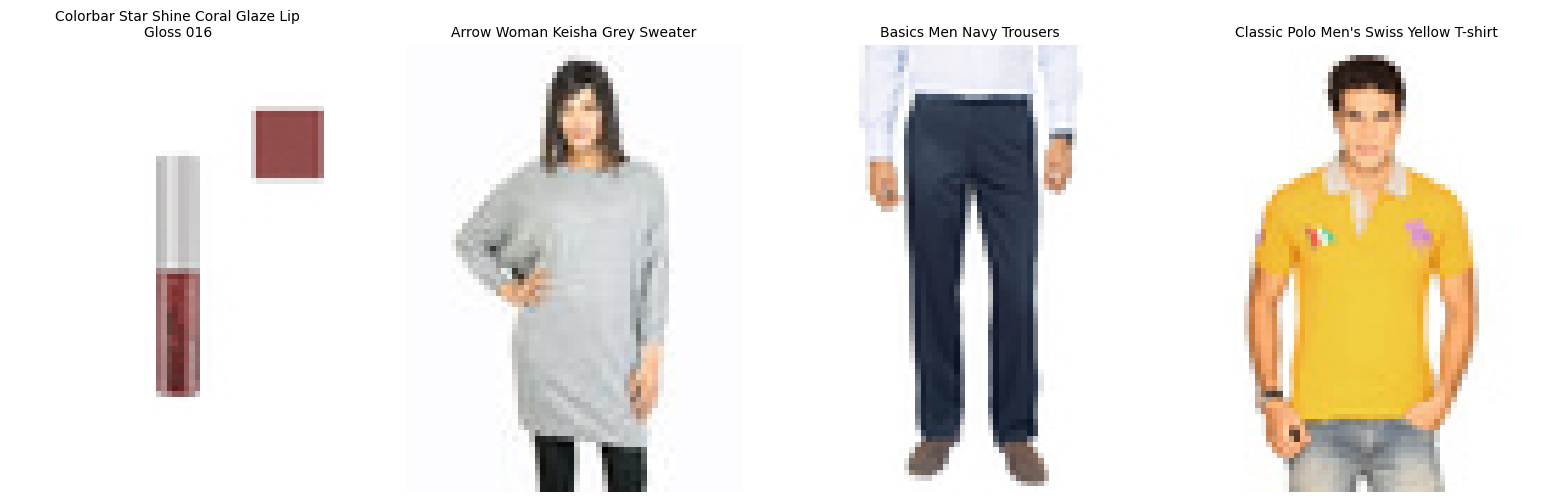

In [7]:
import textwrap
import random

print("⏳ Downloading Image-Text dataset (Parquet format)...")
# Using a 100% native Parquet dataset to bypass HF script blocks entirely
dataset_full = load_dataset("ashraq/fashion-product-images-small")

# Filter out any rare rows where text might be missing
dataset_full = dataset_full.filter(lambda x: x['productDisplayName'] is not None)

# Take a 10k subset to keep feature extraction under 3 minutes
dataset_subset = dataset_full['train'].select(range(10000))

# Split 80/20
dataset_splits = dataset_subset.train_test_split(test_size=0.2, seed=42)
retrieval_train = dataset_splits['train']
retrieval_test = dataset_splits['test']

print(f"✅ Downloaded! Training images: {len(retrieval_train)} | Testing images: {len(retrieval_test)}")

print("🔍 Visualizing Dataset Examples...")
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
indices = random.sample(range(len(retrieval_train)), 4)

for i, idx in enumerate(indices):
    sample = retrieval_train[idx]
    img = sample['image']
    caption = sample['productDisplayName'] # Fashion dataset uses this key

    # Wrap the caption text so it fits nicely above the image
    wrapped_caption = "\n".join(textwrap.wrap(caption, width=40))
    axes[i].imshow(img)
    axes[i].set_title(wrapped_caption, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

> 📝 **Reflection 4**
>
> *Compare this dataset with a standard classiifcaiton dataset as CIFAR-100. How does the two datasets differ? How does the classification task differ from the task of finding the image related to a given caption?*
>
> Your text

We will now proceed with feature extraction:

In [8]:
def collate_retrieval(batch):
    images = torch.stack([preprocess(item['image'].convert('RGB')) for item in batch])
    # The text column in this dataset is 'productDisplayName'
    captions = [item['productDisplayName'] for item in batch]
    return images, captions

def extract_retrieval_features(hf_dataset):
    # We can use a batch size of 128 here for faster extraction
    loader = DataLoader(hf_dataset, batch_size=128, collate_fn=collate_retrieval, num_workers=2)
    img_feats, txt_feats = [], []
    with torch.no_grad():
        for images, captions in tqdm(loader, desc="Extracting Features"):
            images = images.to(device)
            text_tokens = clip.tokenize(captions, truncate=True).to(device)

            img_feats.append(model_clip.encode_image(images).cpu())
            txt_feats.append(model_clip.encode_text(text_tokens).cpu())

    return torch.cat(img_feats), torch.cat(txt_feats)

print("\n➡️ Extracting Training Features...")
train_img, train_txt = extract_retrieval_features(retrieval_train)

print("\n➡️ Extracting Testing Features...")
test_img, test_txt = extract_retrieval_features(retrieval_test)

# Normalize
train_img_norm = F.normalize(train_img.float(), p=2, dim=1)
train_txt_norm = F.normalize(train_txt.float(), p=2, dim=1)
test_img_norm = F.normalize(test_img.float(), p=2, dim=1)
test_txt_norm = F.normalize(test_txt.float(), p=2, dim=1)


➡️ Extracting Training Features...


Extracting Features: 100%|██████████| 63/63 [00:33<00:00,  1.88it/s]



➡️ Extracting Testing Features...


Extracting Features: 100%|██████████| 16/16 [00:09<00:00,  1.75it/s]


## Part 3: Off-the-Shelf Retrieval Evaluation (Baseline)
How good is the raw CLIP space at matching these detailed fashion product names to their respective images *before* we do any training? We evaluate using **Recall@K**.
### Understanding Recall@K

In Information Retrieval, accuracy is often too strict. If a user searches for a specific blue shirt, and the exact shirt is the 2nd result instead of the 1st, the search engine still did a great job! **Recall@K** measures this relaxed accuracy.

It answers the question: *Out of all my queries, for what percentage did the correct, ground-truth image appear in the top $K$ retrieved results?*
* **Recall@1**: The correct image is the absolute #1 most similar result (Very strict).
* **Recall@5**: The correct image is anywhere in the top 5 results.
* **Recall@10**: The correct image is anywhere in the top 10 results.



> ☑️ **TODO 3: Implement Recall@K Evaluation**
>
> For each text query, find the top $K$ most similar images. If the correct image (the one sharing the same index) is in the top $K$, it counts as a success.

In [9]:
def compute_recall(image_features, text_features, k_vals=[1, 5, 10]):
    """
    Computes Recall@K for Text-to-Image retrieval.
    """
    # 1. Compute similarity matrix (N_text, N_image)
    # sim_matrix = ...
    # <YOUR CODE HERE>
    
    # </YOUR CODE HERE>

    recalls = {}
    N = len(text_features)

    for k in k_vals:
        # 2. Get top-k indices for each text
        # <YOUR CODE HERE>
        # top_k_indices = ...
        
        # </YOUR CODE HERE>

        # 3. Check if ground truth (diagonal index) is in top-k
        ground_truth = torch.arange(N).unsqueeze(1).to(top_k_indices.device)
        correct = (top_k_indices == ground_truth).any(dim=1)

        # 4. Calculate percentage
        # recalls[f"R@{k}"] = ...
        # <YOUR CODE HERE>
        
        # </YOUR CODE HERE>
    return recalls

print("\n📊 Evaluating Off-the-Shelf Retrieval on Test Set (RAW CLIP)...")
raw_recalls = compute_recall(test_img_norm, test_txt_norm)
print(f"Baseline Recalls -> R@1: {raw_recalls['R@1']:.2f}% | R@5: {raw_recalls['R@5']:.2f}% | R@10: {raw_recalls['R@10']:.2f}%")


📊 Evaluating Off-the-Shelf Retrieval on Test Set (RAW CLIP)...
Baseline Recalls -> R@1: 18.00% | R@5: 47.65% | R@10: 61.70%


Let's visualize an off-the-shelf retrieval!

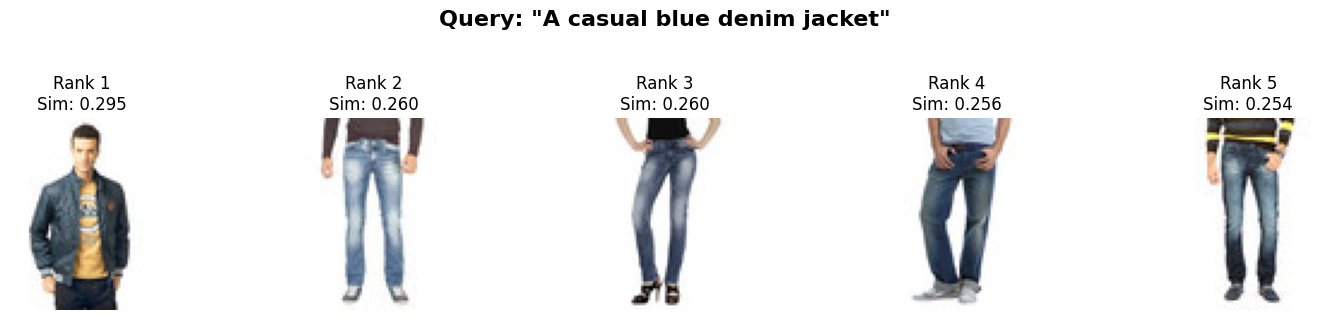

In [10]:
# %%
def visualize_retrieval(query_text, hf_dataset, image_features, text_mapper=None, k=5):
    with torch.no_grad():
        text_tokens = clip.tokenize([query_text], truncate=True).to(device)
        txt_feat = model_clip.encode_text(text_tokens).float()
        if text_mapper is not None:
            text_mapper.eval().to(device)
            txt_feat = text_mapper(txt_feat)
        txt_feat = F.normalize(txt_feat, p=2, dim=1).cpu()

    sims = (txt_feat @ image_features.T).squeeze()
    top_k_idx = sims.topk(k).indices.numpy()

    fig, axes = plt.subplots(1, k, figsize=(15, 3))
    fig.suptitle(f'Query: "{query_text}"', fontsize=16, fontweight='bold', y=1.05)

    for i, idx in enumerate(top_k_idx):
        raw_img = hf_dataset[int(idx)]['image']
        axes[i].imshow(raw_img)
        axes[i].set_title(f"Rank {i+1}\nSim: {sims[idx]:.3f}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Run a query suitable for the fashion dataset
my_query = "A casual blue denim jacket"
# Or you can use a real prompt from the dataset: sample_query = retrieval_test[42]['productDisplayName']

visualize_retrieval(my_query, retrieval_test, test_img_norm, k=5)

> 📝 **Reflection 5**
>
> *Is the retrieval accurate? Can it be improved? What is happening?*
>
> Your text

## Part 4: Adapter Fine-Tuning (Embedding Compression)
Storing 512-dimensional vectors is expensive. We will train an **MLP Adapter** to project these embeddings down to **256 dimensions** and fine-tune them using **InfoNCE loss**. Does specializing the space improve or hurt retrieval?

*Note: Training on small datasets risks overfitting. We add Dropout, BatchNorm, and Weight Decay to counteract this.*



> ☑️ **TODO 4: Implement the Adapter and InfoNCE Loss**

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



🚀 Training Multimodal Adapters...


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ adapter_v │ CLIPAdapter      │  395 K │ train │     0 │
│ 1 │ adapter_t │ CLIPAdapter      │  395 K │ train │     0 │
│ 2 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 790 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 790 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (32) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


adapter/loss,█▅▅▄▃▂▂▁▂
epoch,▁▂▃▄▄▅▆▇█
trainer/global_step,▁▂▃▄▅▅▆▇█
adapter/loss,0.65095
epoch,14
trainer/global_step,449


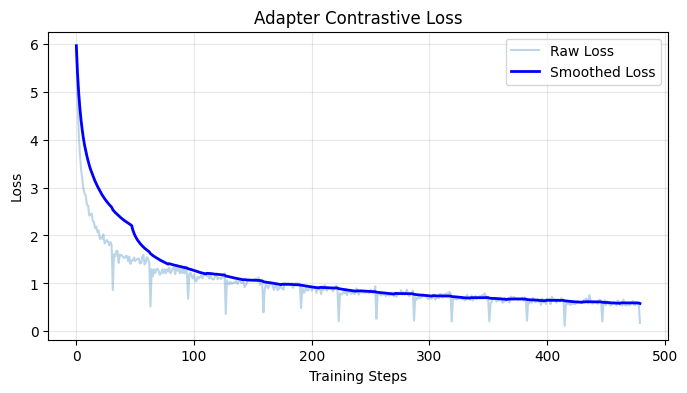

In [11]:
class CLIPAdapter(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=512, output_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

class RetrievalTask(pl.LightningModule):
    def __init__(self, adapter_v, adapter_t, lr=1e-3, temperature=0.07):
        super().__init__()
        self.adapter_v = adapter_v
        self.adapter_t = adapter_t
        self.lr = lr
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss()
        self.train_loss_hist = []

    def training_step(self, batch, batch_idx):
        img_emb, txt_emb = batch


        # 1. Project and L2 normalize
        # define z_v and z_t
        # <YOUR CODE HERE>
        
        # </YOUR CODE HERE>

        # 2. Similarity matrix
        # define the logits and remember to divide them by the temperature
        # logits = ...
        # <YOUR CODE HERE>
        
        # </YOUR CODE HERE>

        # 3. Symmetric Loss
        labels = torch.arange(len(z_v)).to(self.device)

        # the CLIP loss
        loss = (self.criterion(logits, labels) + self.criterion(logits.T, labels)) / 2

        self.train_loss_hist.append(loss.item())
        self.log("adapter/loss", loss)
        return loss

    def configure_optimizers(self):
        # Using AdamW with weight decay to prevent overfitting
        return torch.optim.AdamW(list(self.adapter_v.parameters()) + list(self.adapter_t.parameters()), lr=self.lr, weight_decay=1e-2)

print("\n🚀 Training Multimodal Adapters...")
train_loader = DataLoader(TensorDataset(train_img_norm, train_txt_norm), batch_size=256, shuffle=True)

adapter_vision = CLIPAdapter(input_dim=512, output_dim=256)
adapter_text = CLIPAdapter(input_dim=512, output_dim=256)
task_retrieval = RetrievalTask(adapter_vision, adapter_text, lr=1e-3)

logger_adapter = WandbLogger(project=WANDB_PROJECT, name="Adapter_Training_Fashion")
trainer_adapter = pl.Trainer(max_epochs=15, accelerator="auto", devices=1, logger=logger_adapter, enable_checkpointing=False)
trainer_adapter.fit(task_retrieval, train_loader)
wandb.finish()

# Plot Training Curve
plot_smoothed_curve(task_retrieval.train_loss_hist, "Adapter Contrastive Loss")

### Evaluate Fine-Tuned Adapter Retrieval
Now we extract the adapted features and compute the new Recall metrics.


📊 Evaluating Adapter Retrieval Performance...
   Metric Raw CLIP (512d) Adapter (256d)
 Recall@1          18.00%         32.25%
 Recall@5          47.65%         68.25%
Recall@10          61.70%         81.80%


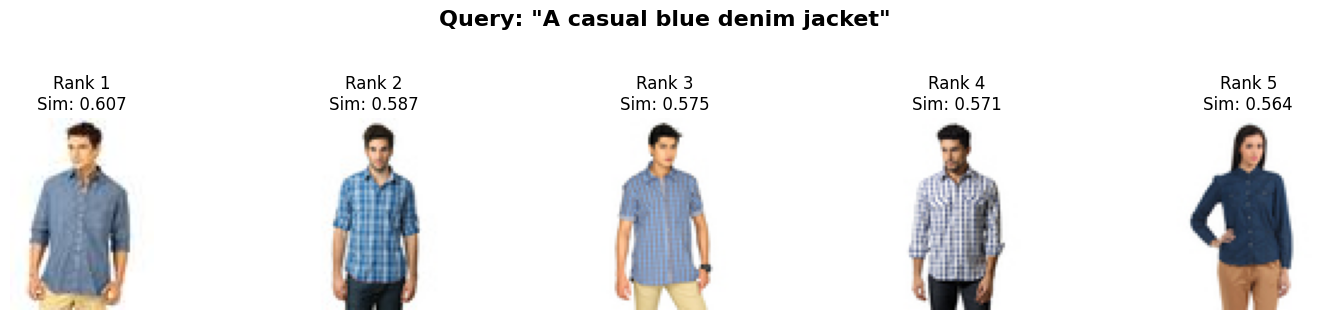

In [12]:
# %%
adapter_vision.eval().to(device)
adapter_text.eval().to(device)

with torch.no_grad():
    adapt_img_feats = F.normalize(adapter_vision(test_img_norm.to(device)), p=2, dim=1).cpu()
    adapt_txt_feats = F.normalize(adapter_text(test_txt_norm.to(device)), p=2, dim=1).cpu()

print("\n📊 Evaluating Adapter Retrieval Performance...")
adapt_recalls = compute_recall(adapt_img_feats, adapt_txt_feats)

results_df = pd.DataFrame({
    'Metric': ['Recall@1', 'Recall@5', 'Recall@10'],
    'Raw CLIP (512d)': [f"{raw_recalls['R@1']:.2f}%", f"{raw_recalls['R@5']:.2f}%", f"{raw_recalls['R@10']:.2f}%"],
    'Adapter (256d)': [f"{adapt_recalls['R@1']:.2f}%", f"{adapt_recalls['R@5']:.2f}%", f"{adapt_recalls['R@10']:.2f}%"]
})
print(results_df.to_string(index=False))

sample_query = "A casual blue denim jacket"

# Visualize with adapter
visualize_retrieval(sample_query, retrieval_test, adapt_img_feats, text_mapper=adapter_text, k=5)

> 📝 **Reflection 6**
>
> *Compare the results after and before training. Did training work as expected? Briefly comment on how performence was affected by the trained adapter.*
>
> Your text


---
**Submission:**
Please wrap up your code, ensure your WandB logs are synced (include the link in your notebook), and submit your `.ipynb` file via email.